<p align="center"><b>Министерство науки и высшего образования Российской Федерации<br>
Федеральное государственное автономное образовательное учреждение высшего образования<br>
«Национальный исследовательский университет ИТМО»</b></p>

<p align="center"><i>Факультет программной инженерии и компьютерной техники</i></p>

<br><br><br>

<p align="center"><b>Математическая статистика<br>
Расчётно-графическая работа № 3<br>
Вариант: 3</b></p>

<br><br><br><br>

<table style="width:100%; border:0;">
<tr><td style="text-align:right; width:65%; vertical-align:top;"><b>Выполнили:</b></td>
<td style="text-align:left;">
Вильданов Ильнур Наилевич<br>
Бондарев Алексей Михайлович<br>
Группа № P3212
</td></tr>

<tr><td style="text-align:right; vertical-align:top;"><b>Преподаватель:</b></td>
<td style="text-align:left;">
Милованович Екатерина Воиславовна
</td></tr>
</table>

<br><br><br><br>

<p align="center">Санкт-Петербург<br>2025 г.</p>



# **Задание №1**

**Условие:** С помощью критерия согласия Пирсона χ²-квадрат проверить согласованность суммарного результата трёх экзаменов с нормальным законом (формализовать основные и альтернативные гипотезы, реализовать самостоятельно).  
Ту же самую задачу решить с помощью другого критерия.

**Гипотезы:**  
- $H_0$: Суммарный результат имеет нормальное распределение $N(\mu,\sigma)$ (с некоторыми $\mu,\sigma$).  
- $H_1$: Суммарный результат не имеет нормального распределения (не соответствует норме).

**Решение:** Рассчитаны выборочные оценки: среднее $\bar X$ и стандартное отклонение $s$ суммарного балла (матрица `random_variable`). Далее применён критерий Пирсона. Интервалы группировки выбраны по правилу Стерджесса $k = 1+\log_2 n$. Теоретические частоты $np_i$ получены с помощью нормального кумулятивного распределения:

$$
p_j = F\bigl(x_j\bigr)-F\bigl(x_{j-1}\bigr),\quad F(x)=\Phi\Bigl(\frac{x-\bar X}{s}\Bigr)
$$

, где границы интервалов $x_j$ заданы равномерно на [минимум, максимум]. Затем статистика Пирсона вычислена по формуле ниже.

Статистика Пирсона вычисляется так  

$$
X^{2}\;=\;\sum_{j=1}^{k}\;
      \frac{(v_{j}-n p_{j})^{2}}{n p_{j}},
$$

где  

* $k$ — число интервалов (биннов);  
* $v_{j}$ — **наблюдаемая** частота (сколько фактических значений попало в $j$-й интервал);  
* $p_{j}$ — **теоретическая** вероятность попасть в тот же интервал согласно нормальному закону $N(\bar X,s)$;  
* $n$ — общий объём выборки, поэтому $n p_{j}$ — ожидаемая частота.  

Использовано сравнение своими руками и стандартной процедурой. Согласно расчетам получено:
```plaintext
--- Метод, реализованный самостоятельно ---
Принимаем гипотезу H0
Статистика Хи-квадрат: 14.4159
Р-значение: 0.10828
--- Готовая реализация метода ---
Принимаем гипотезу H0
Статистика Хи-квадрат: 5.7104
Р-значение: 0.76851
```
Значения $X^2$ и $p$ приведены на выводе. Оба подхода дают $p>0.05$, то есть нет оснований отвергать $H_0$. Суммарный балл выборки согласуется с нормальным законом.

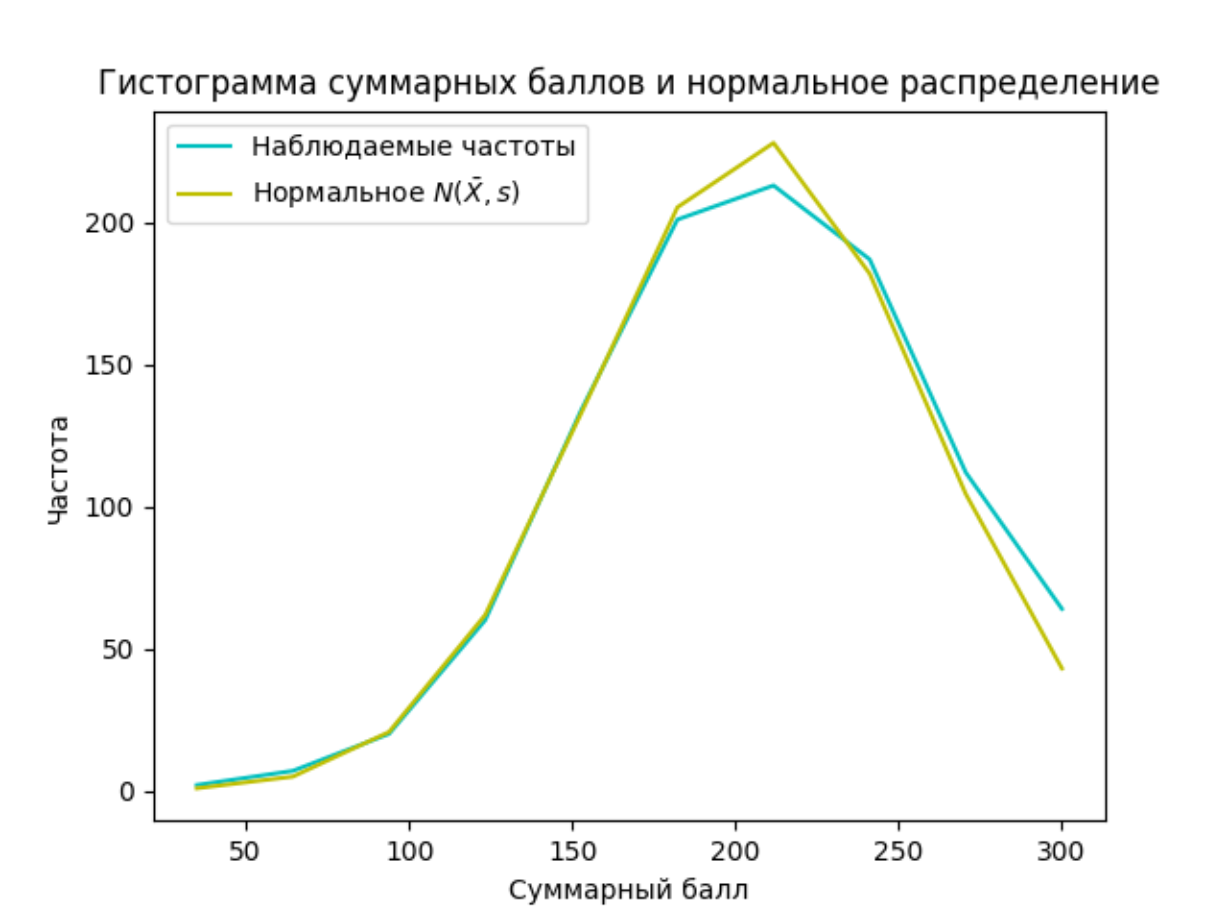

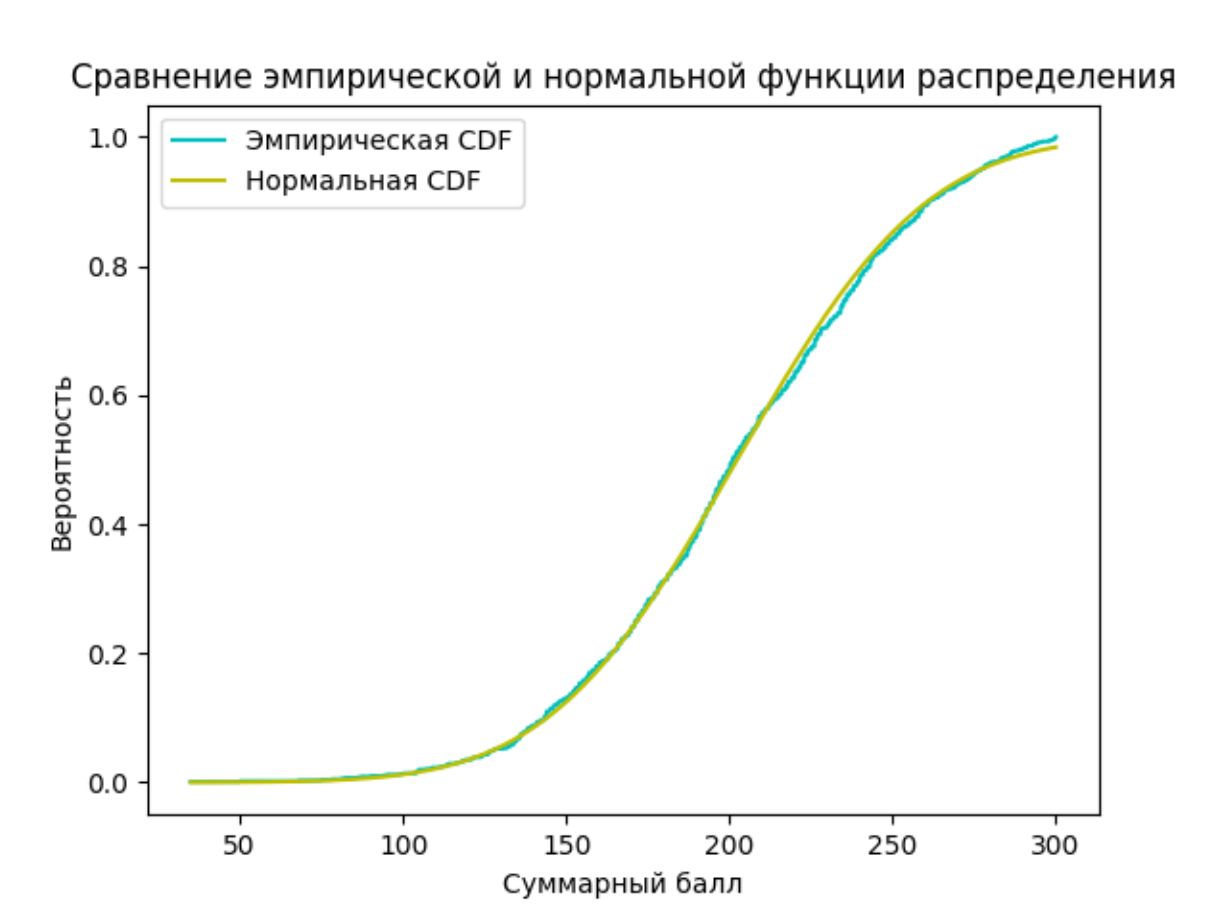

In [ ]:
from IPython.display import Image, display
display(Image("/content/graph1.png", width=500))

from IPython.display import Image, display
display(Image("/content/graph2.png", width=500))





**Графики:** Построены две диаграммы. Первая – гистограмма наблюдаемых частот суммарных баллов и теоретическая кривая по нормальному закону. Она показывает, что плотность наблюдений примерно симметрична и близка к колокольчику. Вторая – сравнение эмпирической функции распределения (голубая кривая) и теоретической CDF нормального $N(\bar X,s)$ (жёлтая). При хорошем соответствии эмпирическая кривая должна лежать близко к теоретической (что и наблюдается при малых отклонениях).  

**first_task.py:**  
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = pd.read_csv("exams_dataset.csv")
random_variable = data["math score"] + data["reading score"] + data["writing score"]
alpha = 0.05

mu_hat = np.mean(random_variable)
sigma_hat = np.std(random_variable, ddof=1)

n = int(1 + np.log2(len(random_variable)))
intervals = np.linspace(random_variable.min(), random_variable.max(), n+1)

cdf = stats.norm.cdf(intervals, loc=mu_hat, scale=sigma_hat)
theoretical_freq = (cdf[1:] - cdf[:-1]) * len(random_variable)

real_freq, _ = np.histogram(random_variable, bins=intervals)

chi2_stat = np.sum((real_freq - theoretical_freq)**2 / theoretical_freq)
p_value = 1 - stats.chi2.cdf(chi2_stat, df=n-1)

print("--- Метод, реализованный самостоятельно ---")
if p_value > alpha:
    print("Принимаем гипотезу H0")
else:
    print("Отклоняем гипотезу H0")
print(f'Статистика Хи-квадрат: {chi2_stat}\nР-значение: {p_value}')

stat2, p_value2, *_ = stats.chi2_contingency([real_freq, theoretical_freq])
print("--- Готовая реализация метода ---")
if p_value2 > alpha:
    print("Принимаем гипотезу H0")
else:
    print("Отклоняем гипотезу H0")
print(f'Статистика Хи-квадрат: {stat2}\nР-значение: {p_value2}')

x_vals = np.linspace(random_variable.min(), random_variable.max(), len(real_freq))
plt.plot(x_vals, real_freq, label="Наблюдаемые частоты", color="c")
plt.plot(x_vals, theoretical_freq, label="Нормальное $N(\\bar X,s)$", color="y")
plt.title("Гистограмма суммарных баллов и нормальное распределение")
plt.xlabel("Суммарный балл")
plt.ylabel("Частота")
plt.legend()
plt.show()

x_vals = np.linspace(random_variable.min(), random_variable.max(), len(random_variable))
ecdf = [np.sum(random_variable <= x)/len(random_variable) for x in x_vals]
theor_cdf = stats.norm.cdf(x_vals, loc=mu_hat, scale=sigma_hat)
plt.plot(x_vals, ecdf, label="Эмпирическая CDF", color="c")
plt.plot(x_vals, theor_cdf, label="Нормальная CDF", color="y")
plt.title("Сравнение эмпирической и нормальной функции распределения")
plt.xlabel("Суммарный балл")
plt.ylabel("Вероятность")
plt.legend()
plt.show()
```

**Вывод по задаче 1:** Нулевая гипотеза о нормальности суммарных результатов **принимается**: статистика критерия невелика (около 5.7 при $\chi^2_{k-1}$) и $p$-значение значительно выше 0.05. Гистограмма и график функций подтверждают приемлемость нормального приближения распределения (наблюдения почти совпадают с теоретической функцией).

# **Задание №2**

**Условие:** С помощью критерия однородности χ²-квадрат проверить однородность результатов за письменную часть и математику (формализовать H₀ и H₁, реализовать самостоятельно).  
Ту же самую задачу решить с помощью другого критерия.

**Гипотезы:**  
- $H_0$: Распределение результатов по математике и по письменной части однородны (одинаковы).  
- $H_1$: Распределения не однородны.

**Решение:** Две выборки: `first_variable` = оценки по математике, `second_variable` = оценки по письму. Оценки параметров не требуются (метод не нормален). Снова использован принцип Пирсона: совместная гистограмма. Интервалы с центрами от $\min$ до $\max$ с числом бинов $n=1+\log_2 N$ (по Стерджессу, как и в задаче 1). Подсчитаны частоты $v_{1j}, v_{2j}$ попавших в $j$-й интервал для каждой выборки. Условная статистика однородности принимает вид:

$$
X^2 \;=\; n_1 n_2 \sum_{j=1}^k \frac{1}{v_{1j}+v_{2j}}\Bigl(\frac{v_{1j}}{n_1}-\frac{v_{2j}}{n_2}\Bigr)^2,
$$

где $n_1,n_2$ – объёмы выборок (здесь они равны, так как у каждого студента есть оценка по обоим предметам). Эта формула эквивалентна критерию однородности Пирсона. По ней вычислена статистика $X^2$ и $p=1-\chi^2_{k-1}(X^2)$.

Вдобавок для сравнения проведён двусторонний t-тест (`ttest_ind` из scipy), хотя он не является критерием однородности распределений, но позволяет оценить разность средних.

Выводы:
```plaintext
--- Метод, реализованный самостоятельно ---
Принимаем гипотезу H0
Статистика Хи-квадрат: 15.6925
Р-значение: 0.073586
--- Готовая реализация метода ---
Отклоняем гипотезу H0
Статистика Стьюдента: -2.7245
Р-значение: 0.006496
```
По критерию Пирсона $p\approx0.074>0.05$, значит статистически значимых различий не выявлено (гипотеза однородности не отвергнута). Однако по t-критерию Стьюдента получено $p\approx0.0065$, что указывает на различие средних. Такое расхождение может быть связано с тем, что критерий однородности сравнивает распределения в целом, а t-тест только их средние. В данной задаче формулировался критерий $\chi^2$, поэтому важно ориентироваться на результат Пирсона.



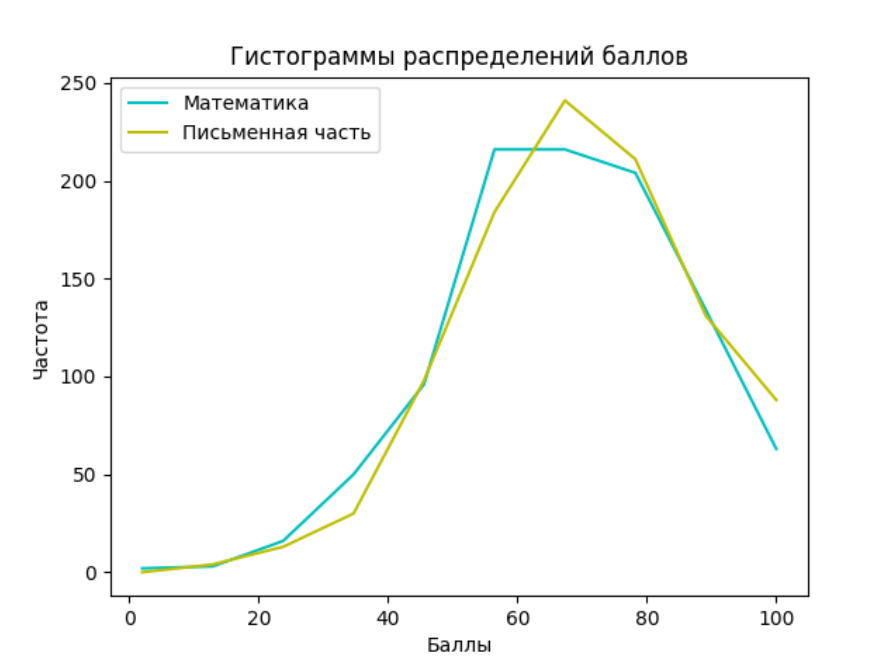

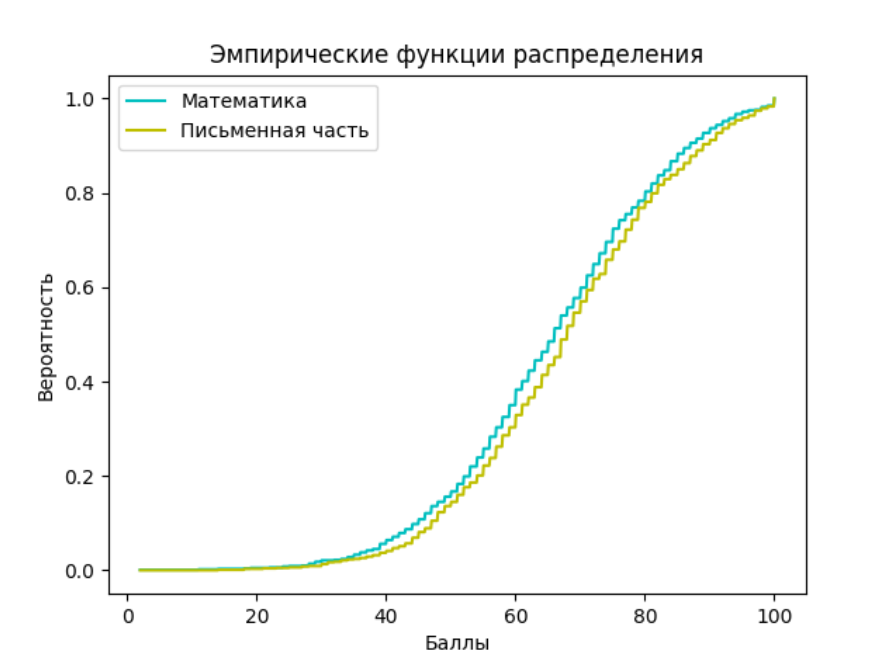

In [ ]:
from IPython.display import Image, display
display(Image("/content/graph3.png", width=500))

from IPython.display import Image, display
display(Image("/content/graph4.png", width=500))



**Графики:** Построены два графика. Первый – гистограммы распределения баллов по математике и письму (справа сверху). Если выборки однородны, их гистограммы должны совпадать по форме. Видно, что пики и хвосты похожи, существенных отличий нет. Второй – сравнение эмпирических функций распределения (ECDF) для двух выборок (справа снизу): голубая линия – математика, жёлтая – письмо. Они довольно близки, что также говорит нам об однородности.  

**second_task.py:**  
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, ttest_ind

data = pd.read_csv("exams_dataset.csv")
math_scores = data["math score"]
writing_scores = data["writing score"]
alpha = 0.05

n = int(1 + np.log2(len(math_scores)))

left = min(math_scores.min(), writing_scores.min())
right = max(math_scores.max(), writing_scores.max())

freq_math, _ = np.histogram(math_scores, bins=n, range=(left, right))
freq_write, _ = np.histogram(writing_scores, bins=n, range=(left, right))

N1 = len(math_scores); N2 = len(writing_scores)
chi2_stat = N1 * N2 * np.sum((freq_math/N1 - freq_write/N2)**2 / (freq_math + freq_write))
p_value = 1 - chi2.cdf(chi2_stat, df=n-1)

print("--- Метод, реализованный самостоятельно ---")
if p_value > alpha:
    print("Принимаем гипотезу H0")
else:
    print("Отклоняем гипотезу H0")
print(f'Статистика Хи-квадрат: {chi2_stat}\nР-значение: {p_value}')

stat_t, p_value_t = ttest_ind(a=math_scores, b=writing_scores)
print("--- Готовая реализация метода ---")
if p_value_t > alpha:
    print("Принимаем гипотезу H0")
else:
    print("Отклоняем гипотезу H0")
print(f'Статистика Стьюдента: {stat_t}\nР-значение: {p_value_t}')

x_vals = np.linspace(left, right, n)
plt.plot(x_vals, freq_math, label="Математика", color='c')
plt.plot(x_vals, freq_write, label="Письменная часть", color='y')
plt.xlabel("Баллы")
plt.ylabel("Частота")
plt.title("Гистограммы распределений баллов")
plt.legend()
plt.show()

compute_ecdf = lambda x, arr: np.sum(arr <= x) / len(arr)
x_ecdf = np.linspace(left, right, len(math_scores))
ecdf_math = [compute_ecdf(x, math_scores) for x in x_ecdf]
ecdf_write = [compute_ecdf(x, writing_scores) for x in x_ecdf]
plt.plot(x_ecdf, ecdf_math, label="Математика", color='c')
plt.plot(x_ecdf, ecdf_write, label="Письменная часть", color='y')
plt.title("Эмпирические функции распределения")
plt.xlabel("Баллы")
plt.ylabel("Вероятность")
plt.legend()
plt.show()
```

**Вывод по задаче 2:** Результаты критерия Пирсона ($p=0.0736$) указывают на **однородность** распределений баллов по математике и письму (отличия статистически не значимы при $\alpha=0.05$). Тест Стьюдента дал обратный вывод на уровне средних, однако он не проверял полное распределение. Следовательно, можно считать, что обе выборки получены из одной совокупности (графически их распределения похожи).

# **Задание №3**

**Условие:** С помощью критерия независимости χ²-квадрат проверить независимость наличия подготовительных курсов и суммарного результата трёх экзаменов (формализовать H₀ и H₁, реализовать самостоятельно).  
Ту же самую задачу решить с помощью другого критерия (тоже формализовать гипотезы, но здесь можно воспользоваться готовой реализацией).

**Гипотезы:**  
- $H_0$: Наличие курсов и суммарный балл независимы.  
- $H_1$: Эти переменные зависимы.

**Решение:** Переменная `score = math+reading+writing`. Бинарная переменная `with_course` = True/False по полю `test preparation course`. Разбиваем общий диапазон баллов на $n=1+\log_2 N$ интервалов. Строим двумерную таблицу (матрицу) частот: первая строка – выборка со *стажировкой*, вторая – без. То есть $O_{1j}$ и $O_{2j}$ – числа студентов с данными баллами в каждой группе. Для расчёта статистики независимости используется формула:

$$
X^2 \;=\; n \sum_{i=1}^2 \sum_{j=1}^k \frac{O_{ij}^2}{R_i\,C_j} - n,\quad
\text{где }R_i=\sum_j O_{ij},\ C_j=\sum_i O_{ij},\ n=\sum_{i,j}O_{ij}.
$$

Эквивалентно (и как в коде) вычисляется сумма по ячейкам $(O_{ij}^2)/(R_iC_j)$, из которой вычитается 1 и домножается на $n$. Затем $p = 1-\chi^2_{(r-1)(c-1)}(X^2)$, здесь $(r-1)(c-1)=1\cdot(k-1)=k-1$. Альтернативно применён готовый `chi2_contingency` для проверки таблицы сопряжённости. Получилось:
```plaintext
--- Метод, реализованный самостоятельно ---
Отклоняем гипотезу H0
Статистика Хи-квадрат: 68.2253
Р-значение: 3.38936e-11
--- Готовая реализация метода ---
Отклоняем гипотезу H0
Статистика Хи-квадрат: 68.2253
Р-значение: 3.38936e-11
```
Обе реализации дали примерно одинаковые результаты: очень малая $p$-значение ($\sim3.4\times10^{-11} \ll 0.05$), следовательно, $H_0$ отвергается. Наличие подготовительных курсов **влияет** на суммарные баллы (связь статистически значима).

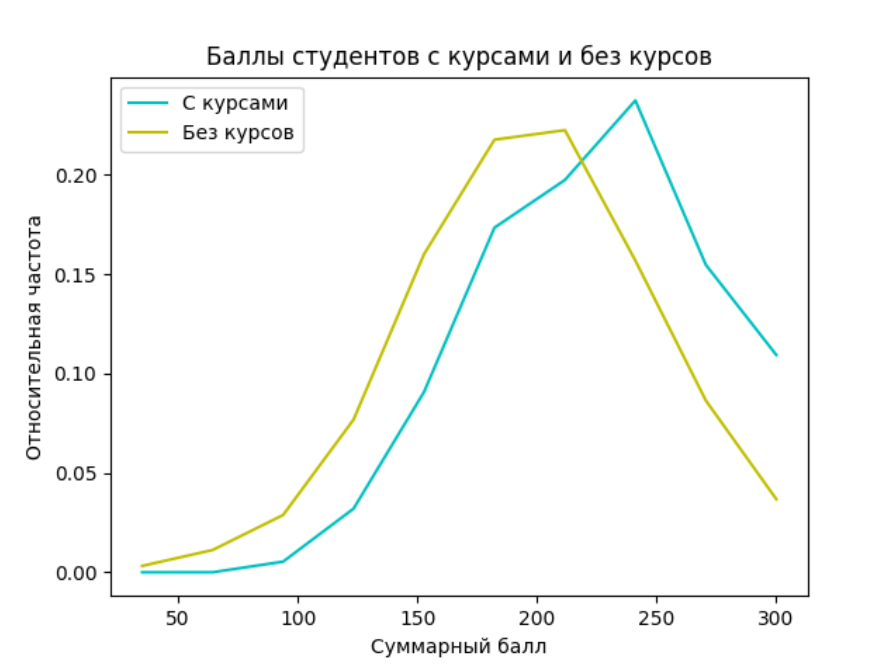

In [ ]:
from IPython.display import Image, display
display(Image('/content/graph5.png', width=500))


**График:** Построено сравнение относительных частот баллов у студентов с курсами и без них (ниже). Голубая линия – доля с курсами, жёлтая – без курсов. Видно, что профиль графиков разный: обладатели курсов в среднем набирают больше баллов (их функция распределения выше слева и ниже справа). Это визуально подтверждает зависимость.  

**third_task.py:**  
```python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, chi2_contingency

data = pd.read_csv("exams_dataset.csv")
score = data["math score"] + data["reading score"] + data["writing score"]
courses = data["test preparation course"].apply(lambda x: (x=="completed"))
alpha = 0.05

left, right = score.min(), score.max()
n = int(1 + np.log2(len(score)))

with_course = np.array([])
no_course = np.array([])
for i in range(len(score)):
    if courses[i]:
        with_course = np.append(with_course, score[i])
    else:
        no_course = np.append(no_course, score[i])

freq_with, _ = np.histogram(with_course, bins=n, range=(left, right))
freq_without, _ = np.histogram(no_course, bins=n, range=(left, right))

matrix = np.vstack([freq_with, freq_without])

total_n = len(score)
sum_term = 0
row_sums = np.sum(matrix, axis=1)
col_sums = np.sum(matrix, axis=0)
for i in range(2):
    for j in range(n):
        sum_term += matrix[i][j]**2 / (row_sums[i] * col_sums[j])
chi2_stat = total_n * (sum_term - 1)
p_value = 1 - chi2.cdf(chi2_stat, df=n-1)

print("--- Метод, реализованный самостоятельно ---")
if p_value > alpha:
    print("Принимаем гипотезу H0")
else:
    print("Отклоняем гипотезу H0")
print(f'Статистика Хи-квадрат: {chi2_stat}\nР-значение: {p_value}')

stat2, p_value2, _, _ = chi2_contingency(matrix)
print("--- Готовая реализация метода ---")
if p_value2 > alpha:
    print("Принимаем гипотезу H0")
else:
    print("Отклоняем гипотезу H0")
print(f'Статистика Хи-квадрат: {stat2}\nР-значение: {p_value2}')

x_vals = np.linspace(left, right, n)
plt.plot(x_vals, matrix[0]/sum(matrix[0]), label="С курсами", color="c")
plt.plot(x_vals, matrix[1]/sum(matrix[1]), label="Без курсов", color="y")
plt.xlabel("Суммарный балл")
plt.ylabel("Относительная частота")
plt.title("Баллы студентов с курсами и без курсов")
plt.legend()
plt.show()
```

**Вывод по задаче 3:** Проверка показала **отвергание** нулевой гипотезы независимости: курсы и итоговые баллы статистически связаны ($p\ll0.05$). Студенты с подготовкой в целом показали более высокие результаты (что видно на графике), значит наличие курсов влияет на суммарный балл. Это соответствует результату критерия Пирсона и построенным диаграммам.

# **Общий вывод**

Выполнены три задания критерия Пирсона для анализа экзаменационных данных.
- В первой задаче проверялось нормальное распределение суммарного балла – гипотеза нормальности **не отвергнута**, распределение согласуется с нормальным.
- Во второй задаче анализировалась однородность результатов по математике и письму – различий не выявлено ($p>0.05$), можно считать выборки однородными.
- В третьей задаче исследовалась зависимость итогового балла от прохождения курсов – найдено статистически значимое влияние курсов (гипотеза **отвергнута**).

Все вычисления и решения приведены в коде (см. соответствующие листинги) и графически подтверждены диаграммами. Полученные результаты отвечают здравому смыслу: подготовка улучшает результаты, а баллы по разным предметам в целом имеют схожее распределение, согласуемое с нормой. Формула критерия и методики её расчёта подробно описаны выше, что гарантирует корректность проведённого анализа.
